# Fractal Number Encoding And Decoding Demo / Демонстрация кодирования и декодирования фрактального числа

**RU.** Этот notebook показывает механику фрактального числа по шагам. Мы берем одно десятичное число, кодируем его во фрактальную форму, разворачиваем параметры генераторов в таблицу состояний и суммарную амплитуду, а затем декодируем сигнал обратно в исходное число.

Путь данных:

```text
число -> mixed-radix digits -> ячейки алфавита (P_i, S_i) -> C_i(t) -> A(t) -> residual peeling -> digits -> число
```

Notebook состоит из двух больших блоков:

1. **Encoding / Кодирование:** число, алфавит, выбранные ячейки, параметры генераторов, таблица состояний и суммарный сигнал.
2. **Decoding / Декодирование:** пошаговое восстановление параметров из остатка, восстановление digits и проверка равенства исходному числу.

**EN.** This notebook demonstrates the mechanics of a fractal number step by step. We take one decimal number, encode it into fractal form, unfold generator parameters into a state table and summed amplitude signal, and then decode the signal back into the original number.

Data path:

```text
number -> mixed-radix digits -> alphabet cells (P_i, S_i) -> C_i(t) -> A(t) -> residual peeling -> digits -> number
```

In [1]:
from pathlib import Path
import math
import sys

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "experiments" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from snn_framework import ChannelAlphabet, MatrixCell, MatrixFractalNumber

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 120)


def plot_alphabet_with_cell(model: MatrixFractalNumber, cell: MatrixCell, ax):
    alphabet = model.channel_alphabet(cell.digit_index)
    max_shift = alphabet.max_period - 1
    valid_counter = 0
    for y, period in enumerate(alphabet.periods):
        for shift in range(max_shift + 1):
            is_valid = shift < period
            facecolor = "#2563EB" if is_valid else "#F3F4F6"
            edgecolor = "#1F2937" if is_valid else "#D1D5DB"
            rect = plt.Rectangle((shift - 0.5, y - 0.5), 1, 1, facecolor=facecolor, edgecolor=edgecolor, linewidth=1)
            ax.add_patch(rect)
            if is_valid:
                ax.text(shift, y, str(valid_counter), ha="center", va="center", color="white", fontsize=9, weight="bold")
                valid_counter += 1
            else:
                ax.text(shift, y, "×", ha="center", va="center", color="#9CA3AF", fontsize=9)
    selected_y = list(alphabet.periods).index(cell.period_ticks)
    ax.scatter([cell.shift_ticks], [selected_y], s=480, facecolors="none", edgecolors="#DC2626", linewidths=3)
    ax.text(cell.shift_ticks, selected_y - 0.4, "selected", ha="center", va="bottom", color="#DC2626", fontsize=10, weight="bold")
    ax.set_xlim(-0.5, max_shift + 0.5)
    ax.set_ylim(len(alphabet.periods) - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks(range(max_shift + 1), labels=[str(s) for s in range(max_shift + 1)])
    ax.set_yticks(range(len(alphabet.periods)), labels=[str(p) for p in alphabet.periods])
    ax.set_xlabel("shift S")
    ax.set_ylabel("period P")
    ax.set_title(f"digit {cell.digit_index}: V={cell.digit_value} -> P={cell.period_ticks}, S={cell.shift_ticks}")
    ax.grid(False)


def state_table_from_samples(samples, digit_count: int, limit: int | None = None) -> pd.DataFrame:
    rows = []
    selected_samples = samples if limit is None else samples[:limit]
    for sample in selected_samples:
        row = {"tick": sample.tick}
        for channel, amplitude in enumerate(sample.channel_amplitudes):
            row[f"C{channel}(t)"] = int(amplitude)
        row["A(t)"] = int(sample.total_amplitude)
        rows.append(row)
    return pd.DataFrame(rows)


def plot_signal_tracks(samples, cells, title: str):
    digit_count = len(cells)
    tick_axis = [sample.tick for sample in samples]
    fig, axes = plt.subplots(digit_count + 1, 1, figsize=(13, 2.2 * (digit_count + 1)), sharex=True)
    for channel, cell in enumerate(cells):
        values = [sample.channel_amplitudes[channel] for sample in samples]
        axes[channel].step(tick_axis, values, where="post", linewidth=2)
        axes[channel].axvline(cell.shift_ticks, color="#DC2626", linestyle="--", alpha=0.8, label=f"S={cell.shift_ticks}")
        axes[channel].set_ylabel(f"C{channel}(t)")
        axes[channel].set_title(f"channel {channel}: P={cell.period_ticks}, S={cell.shift_ticks}, active_width={cell.active_width_ticks}")
        axes[channel].legend(loc="upper right")
    summed = [sample.total_amplitude for sample in samples]
    axes[-1].step(tick_axis, summed, where="post", color="black", linewidth=2.5)
    axes[-1].set_ylabel("A(t)")
    axes[-1].set_xlabel("tick")
    axes[-1].set_title(title)
    fig.tight_layout()
    return fig, axes


def cell_waveform(cell: MatrixCell, ticks: int) -> list[int]:
    active = set(MatrixFractalNumber.cell_active_ticks(cell, ticks=ticks))
    return [1 if tick in active else 0 for tick in range(ticks)]

## A. Encoding / Кодирование

### A1. Choose The Number And Alphabet / Выбираем число и алфавит

**RU.** Начинаем с обычного десятичного числа. Для демонстрации возьмем `348` и двухразрядный диагональный алфавит из статьи:

- digit `0`: periods `{2, 3, 4, 5, 6}`;
- digit `1`: periods `{7, 8, 9, 10}`.

Каждый канал является разрядом фрактального числа. В диагональной модели строка периода `P` содержит `P` допустимых задержек старта, поэтому основание разряда равно:

$$
Base_i = \sum_{P \in periods_i} P
$$

**EN.** We start from an ordinary decimal number. For the demo we use `348` and the two-digit diagonal alphabet from the article. Each channel is one fractal digit. In the diagonal model, period row `P` contains `P` legal start delays, so the digit radix is the sum of row lengths.

### Source Number / Исходное число

,source number,digit count,mixed-radix digits,reconstructed number
0,348,2,"[8, 17]",348


### Fractal Alphabet Summary / Сводка фрактального алфавита

,digit i,period band,period rows,Base_i = sum(P),capacity bits
0,0,2..6,"(2, 3, 4, 5, 6)",20,4.322
1,1,7..10,"(7, 8, 9, 10)",34,5.087


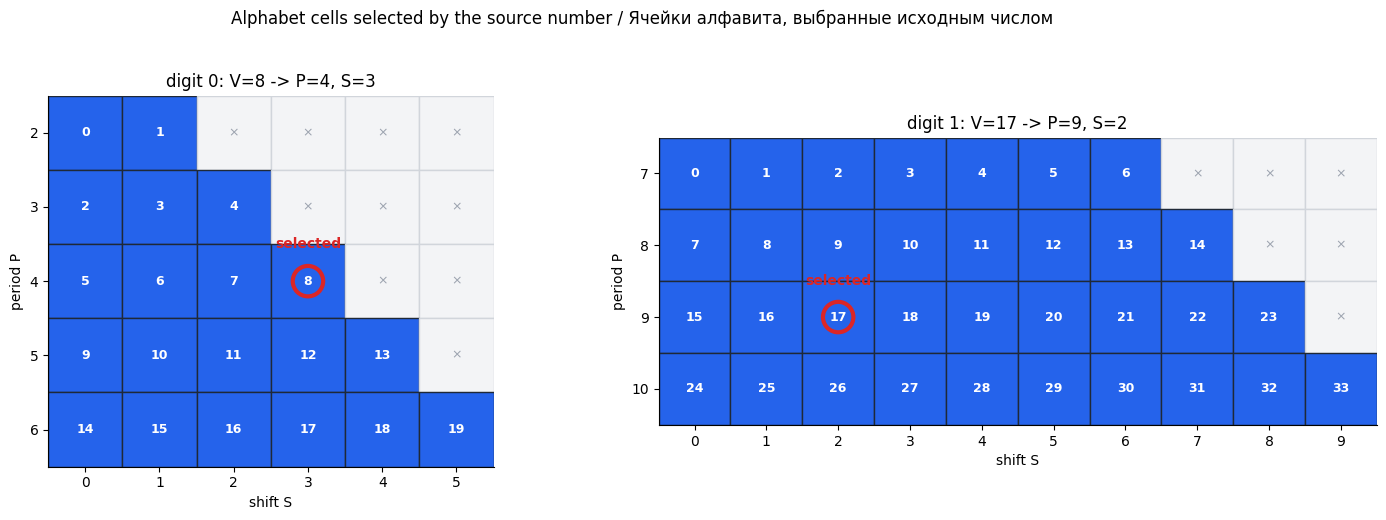

In [2]:
model = MatrixFractalNumber.article_348_alphabet()
value = 348
digit_count = 2

digits = model.encode_digits(value, digit_count=digit_count)
cells = model.encode_cells(value, digit_count=digit_count)

alphabet_rows = []
for channel in range(digit_count):
    alphabet = model.channel_alphabet(channel)
    alphabet_rows.append({
        "digit i": channel,
        "period band": f"{alphabet.periods[0]}..{alphabet.periods[-1]}",
        "period rows": alphabet.periods,
        "Base_i = sum(P)": model.radix(channel),
        "capacity bits": round(math.log2(model.radix(channel)), 3),
    })

number_summary = pd.DataFrame([
    {
        "source number": value,
        "digit count": digit_count,
        "mixed-radix digits": digits,
        "reconstructed number": model.decode_digits(digits),
    }
])

display(Markdown("### Source Number / Исходное число"))
display(number_summary)
display(Markdown("### Fractal Alphabet Summary / Сводка фрактального алфавита"))
display(pd.DataFrame(alphabet_rows))

fig, axes = plt.subplots(1, digit_count, figsize=(15, 5))
for ax, cell in zip(axes, cells):
    plot_alphabet_with_cell(model, cell, ax)
fig.suptitle("Alphabet cells selected by the source number / Ячейки алфавита, выбранные исходным числом", y=1.03)
fig.tight_layout();

### A2. From Digits To Generator Parameters / От разрядов к параметрам генераторов

**RU.** Число `348` раскладывается в mixed-radix digits. Каждый digit превращается в выбранную диагональную ячейку матрицы:

- progressive subtraction выбирает строку, то есть период `P_i`;
- остаток после выбора строки становится задержкой старта `S_i`;
- `active_width` задает половину периода, после которой канал находится в состоянии `1`.

В компактной фрактальной форме число теперь представлено параметрами генераторов.

**EN.** The number `348` is decomposed into mixed-radix digits. Each digit becomes a selected diagonal matrix cell: progressive subtraction selects the period row `P_i`, the remainder becomes start delay `S_i`, and `active_width` defines the half-period threshold after which the channel emits `1`.

In [3]:
cell_rows = []
for cell in cells:
    alphabet = model.channel_alphabet(cell.digit_index)
    prefix_sum = sum(alphabet.periods[:cell.period_index])
    cell_rows.append({
        "digit i": cell.digit_index,
        "Base_i": model.radix(cell.digit_index),
        "digit V_i": cell.digit_value,
        "period_index": cell.period_index,
        "selected P_i": cell.period_ticks,
        "selected S_i": cell.shift_ticks,
        "active_width=floor(P_i/2)": cell.active_width_ticks,
        "digit reconstruction": f"{prefix_sum} + {cell.shift_ticks} = {cell.digit_value}",
    })

cells_df = pd.DataFrame(cell_rows)
display(cells_df)

display(Markdown(
    "**RU.** Формула `digit reconstruction` показывает обратный путь от выбранной ячейки к значению разряда: сумма длин предыдущих строк периода плюс сдвиг.  "
    "\n**EN.** The `digit reconstruction` formula shows the reverse path from the selected cell to the digit value: sum of previous period-row lengths plus shift."
))

,digit i,Base_i,digit V_i,period_index,selected P_i,selected S_i,active_width=floor(P_i/2),digit reconstruction
0,0,20,8,2,4,3,2,5 + 3 = 8
1,1,34,17,2,9,2,4,15 + 2 = 17


**RU.** Формула `digit reconstruction` показывает обратный путь от выбранной ячейки к значению разряда: сумма длин предыдущих строк периода плюс сдвиг.  
**EN.** The `digit reconstruction` formula shows the reverse path from the selected cell to the digit value: sum of previous period-row lengths plus shift.

### A3. Unfolded State Table / Развернутая таблица состояний

**RU.** По выбранным параметрам генераторов можно развернуть таблицу состояний. Каждая строка соответствует одному tick, а столбцы `C0(t)`, `C1(t)` показывают активность отдельных каналов. Последний столбец `A(t)` — это суммарная амплитуда, которую может видеть приемник.

Эта таблица уже не является компактной формой числа. Это runtime-представление, которое процедурно получается из компактных ячеек `(P_i, S_i)`.

**EN.** The selected generator parameters unfold into a state table. Each row is one tick; columns `C0(t)`, `C1(t)` show individual channel activity. The last column `A(t)` is the summed amplitude observed by the receiver. This table is not the compact number; it is a runtime representation generated from compact cells `(P_i, S_i)`.

In [4]:
ticks = 40
samples = model.signal(value, digit_count=digit_count, ticks=ticks)
state_df = state_table_from_samples(samples, digit_count=digit_count, limit=24)
display(state_df)

display(Markdown(
    "**RU.** В первых тактах видна задержка старта: канал молчит до момента, заданного `S_i`, затем начинает полупериодический step-паттерн.  "
    "\n**EN.** The first ticks show the start delay: each channel stays silent until `S_i`, then begins its half-periodic step pattern."
))

,tick,C0(t),C1(t),A(t)
0,0,0,0,0
1,1,0,0,0
2,2,0,0,0
3,3,0,0,0
4,4,0,0,0
5,5,1,0,1
6,6,1,1,2
7,7,0,1,1
8,8,0,1,1
9,9,1,1,2


**RU.** В первых тактах видна задержка старта: канал молчит до момента, заданного `S_i`, затем начинает полупериодический step-паттерн.  
**EN.** The first ticks show the start delay: each channel stays silent until `S_i`, then begins its half-periodic step pattern.

### A4. Summed Amplitude Signal / Суммарный амплитудный сигнал

**RU.** В summed-amplitude режиме приемник видит не отдельные каналы, а их сумму:

$$
A(t) = \sum_i C_i(t)
$$

На графике ниже верхние дорожки показывают отдельные каналы, а нижняя дорожка показывает суммарный сигнал `A(t)`. Красные линии показывают задержку старта `S_i` каждого генератора.

**EN.** In summed-amplitude mode the receiver observes not separated channels, but their sum. The upper tracks show individual channels, and the bottom track shows the summed signal `A(t)`. Red lines mark the start delay `S_i` of each generator.

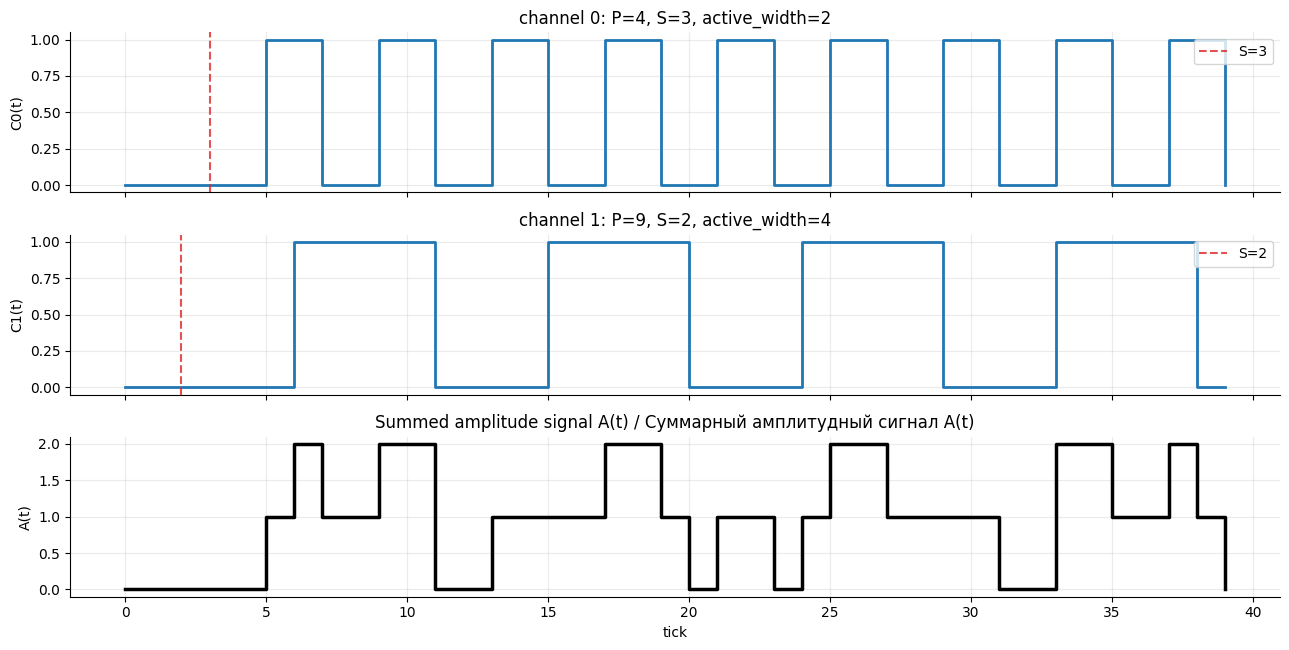

In [5]:
channel_series = [
    [sample.channel_amplitudes[channel] for sample in samples]
    for channel in range(digit_count)
]
summed = [sample.total_amplitude for sample in samples]
plot_signal_tracks(samples, cells, "Summed amplitude signal A(t) / Суммарный амплитудный сигнал A(t)");

## B. Decoding / Декодирование

### B1. Candidate Cells / Допустимые ячейки декодера

**RU.** Декодирование идет от младшего канала к старшим. В нашем примере канал `0` является младшим и более быстрым, канал `1` более старший и медленный.

В summed-amplitude режиме приемник видит только `A(t)`. Поэтому декодер делает residual peeling:

1. берет текущий остаток, сначала это весь `A(t)`;
2. для текущего разряда перебирает допустимые ячейки `(P,S)` его алфавита;
3. находит ячейку, чей step-паттерн лучше всего объясняет часть остатка;
4. вычитает найденный канал из остатка;
5. переходит к следующему разряду.

**EN.** Decoding proceeds from the least significant/high-frequency channel to higher channels. In summed-amplitude mode the receiver sees only `A(t)`, so the decoder performs residual peeling: match one valid cell, subtract its waveform, and continue with the next digit.

In [6]:
candidate_rows = []
for channel in range(digit_count):
    alphabet = model.channel_alphabet(channel)
    candidate_rows.append({
        "channel": channel,
        "period rows": alphabet.periods,
        "allowed shifts per row": [f"P={period}: S=0..{period - 1}" for period in alphabet.periods],
        "candidate_cells(channel)": len(model.candidate_cells(channel)),
        "meaning": "decoder may choose only one valid diagonal matrix cell",
    })

pd.DataFrame(candidate_rows)

,channel,period rows,allowed shifts per row,candidate_cells(channel),meaning
0,0,"(2, 3, 4, 5, 6)","[P=2: S=0..1, P=3: S=0..2, P=4: S=0..3, P=5: S=0..4, P=6: S=0..5]",20,decoder may choose only one valid diagonal matrix cell
1,1,"(7, 8, 9, 10)","[P=7: S=0..6, P=8: S=0..7, P=9: S=0..8, P=10: S=0..9]",34,decoder may choose only one valid diagonal matrix cell


### B2. Residual Peeling Step By Step / Residual peeling по шагам

**RU.** Теперь декодируем только по суммарному сигналу `A(t)`. На каждом шаге показаны три графика: остаток до вычитания, найденный генератор и остаток после вычитания. Красная линия показывает восстановленный сдвиг `S_i`, а желтая область — начальное нулевое окно до первой активной части периода.

**EN.** Now we decode using only the summed signal `A(t)`. Each step shows three plots: residual before subtraction, matched generator, and residual after subtraction. The red line marks recovered shift `S_i`; the yellow region marks the initial zero window before the first active part of the period.

,peeling step,decoded digit i,decoded V_i,decoded P_i,decoded S_i,first active tick,next active tick,residual sum before,residual sum after
0,0,0,8,4,3,5,6,38.0,20.0
1,1,1,17,9,2,6,7,20.0,0.0


**RU.** Восстановленные digits: `[8, 17]`. Восстановленное число: `348`.  
**EN.** Recovered digits: `[8, 17]`. Recovered number: `348`.

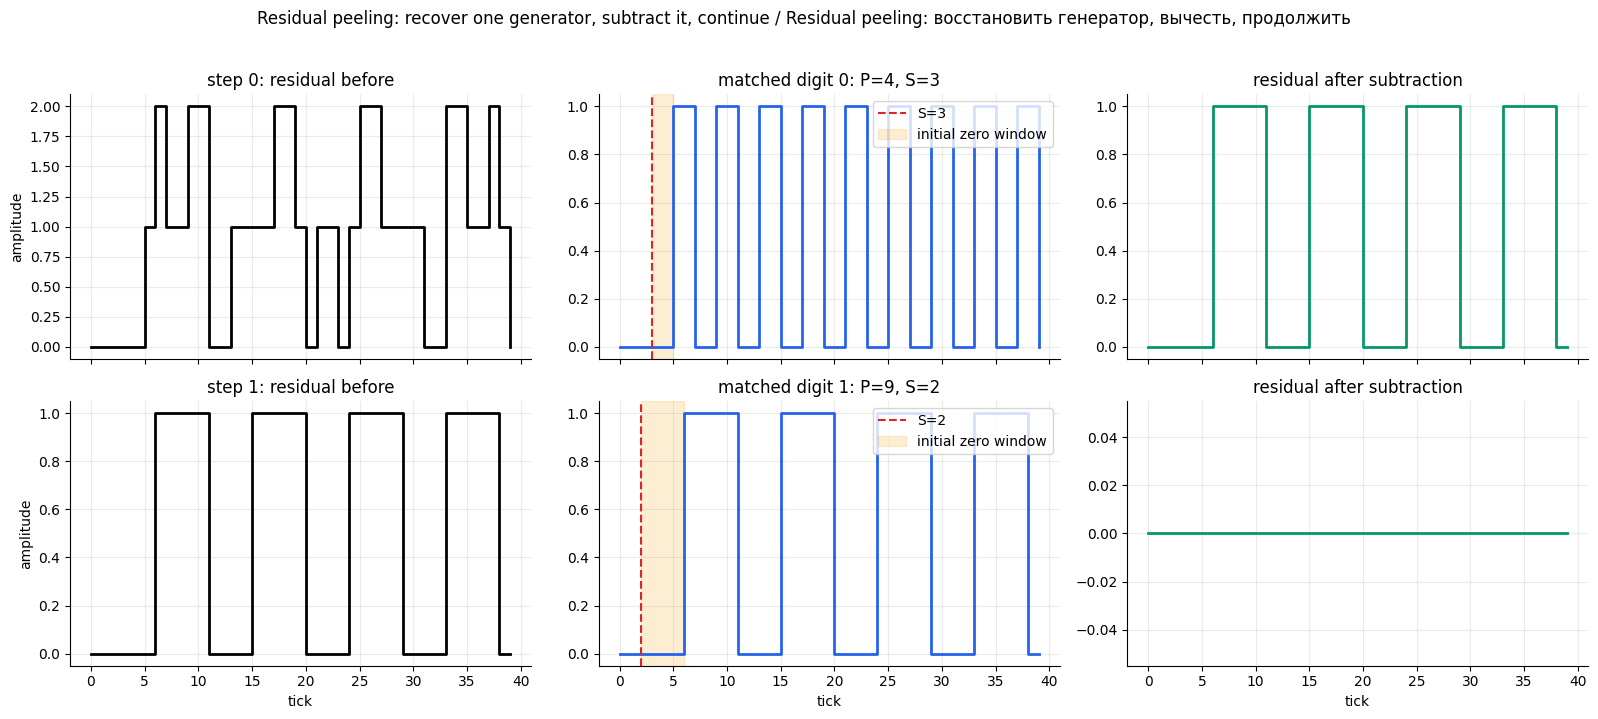

In [7]:
residual = [float(value) for value in summed]
peeling_rows = []
recovered_digits = []
peeling_snapshots = []

tick_axis = list(range(len(residual)))
for channel in range(digit_count):
    residual_before = residual.copy()
    decoded_cell = model._decode_next_cell_from_residual(
        residual,
        digit_index=channel,
        amplitude=1.0,
        threshold=0.5,
    )
    recovered_digits.append(decoded_cell.digit_value)

    decoded_wave = cell_waveform(decoded_cell, ticks=len(residual))
    active_ticks = [tick for tick, value in enumerate(decoded_wave) if value]
    first_active_tick = active_ticks[0] if active_ticks else None
    next_active_tick = active_ticks[1] if len(active_ticks) > 1 else None
    residual_sum_before = sum(residual)

    for tick in active_ticks:
        residual[tick] -= 1.0

    peeling_rows.append({
        "peeling step": channel,
        "decoded digit i": channel,
        "decoded V_i": decoded_cell.digit_value,
        "decoded P_i": decoded_cell.period_ticks,
        "decoded S_i": decoded_cell.shift_ticks,
        "first active tick": first_active_tick,
        "next active tick": next_active_tick,
        "residual sum before": residual_sum_before,
        "residual sum after": sum(residual),
    })
    peeling_snapshots.append((channel, decoded_cell, residual_before, decoded_wave, residual.copy()))

peeling_df = pd.DataFrame(peeling_rows)
display(peeling_df)

display(Markdown(
    f"**RU.** Восстановленные digits: `{recovered_digits}`. Восстановленное число: `{model.decode_digits(recovered_digits)}`.  "
    f"\n**EN.** Recovered digits: `{recovered_digits}`. Recovered number: `{model.decode_digits(recovered_digits)}`."
))

fig, axes = plt.subplots(len(peeling_snapshots), 3, figsize=(16, 3.5 * len(peeling_snapshots)), sharex=True)
if len(peeling_snapshots) == 1:
    axes = [axes]
for row_axes, (channel, decoded_cell, before, wave, after) in zip(axes, peeling_snapshots):
    row_axes[0].step(tick_axis, before, where="post", color="black", linewidth=2)
    row_axes[0].set_title(f"step {channel}: residual before")
    row_axes[0].set_ylabel("amplitude")

    row_axes[1].step(tick_axis, wave, where="post", color="#2563EB", linewidth=2)
    row_axes[1].axvline(decoded_cell.shift_ticks, color="#DC2626", linestyle="--", label=f"S={decoded_cell.shift_ticks}")
    first_one = decoded_cell.shift_ticks + decoded_cell.active_width_ticks
    row_axes[1].axvspan(decoded_cell.shift_ticks, first_one, color="#F59E0B", alpha=0.18, label="initial zero window")
    row_axes[1].set_title(f"matched digit {channel}: P={decoded_cell.period_ticks}, S={decoded_cell.shift_ticks}")
    row_axes[1].legend(loc="upper right")

    row_axes[2].step(tick_axis, after, where="post", color="#059669", linewidth=2)
    row_axes[2].set_title("residual after subtraction")
for ax in axes[-1]:
    ax.set_xlabel("tick")
fig.suptitle("Residual peeling: recover one generator, subtract it, continue / Residual peeling: восстановить генератор, вычесть, продолжить", y=1.02)
fig.tight_layout();

### B3. From Recovered Parameters Back To The Number / Из восстановленных параметров обратно к числу

**RU.** После residual peeling мы знаем восстановленные ячейки `(P_i, S_i)`. По алфавиту каждая ячейка превращается обратно в digit `V_i`, а mixed-radix digits собираются в десятичное число.

**EN.** After residual peeling we know the recovered cells `(P_i, S_i)`. Each cell maps back to digit `V_i` through the alphabet, and mixed-radix digits are assembled into the decimal number.

In [8]:
separated_result = model.decode_channel_signals(channel_series)
summed_result = model.decode_step_signal(summed, digit_count=digit_count)

reconstruction_rows = []
for digit_index, digit_value in enumerate(summed_result.digits):
    cell = model.digit_to_cell(digit_index, digit_value)
    alphabet = model.channel_alphabet(digit_index)
    multiplier = math.prod(model.radix(i) for i in range(digit_index)) if digit_index > 0 else 1
    reconstruction_rows.append({
        "digit i": digit_index,
        "decoded V_i": digit_value,
        "decoded cell (P_i, S_i)": f"({cell.period_ticks}, {cell.shift_ticks})",
        "Base_i": alphabet.radix,
        "place multiplier": multiplier,
        "contribution to number": digit_value * multiplier,
    })

reconstruction_df = pd.DataFrame(reconstruction_rows)
summary_df = pd.DataFrame([
    {"decoder": "separated channels", "digits": separated_result.digits, "number": separated_result.number},
    {"decoder": "summed A(t) residual peeling", "digits": summed_result.digits, "number": summed_result.number},
])

assert separated_result.number == value
assert summed_result.number == value
assert model.decode_digits(list(summed_result.digits)) == value

display(Markdown("### Parameter-To-Number Reconstruction / Восстановление числа из параметров"))
display(reconstruction_df)
display(Markdown("### Final Equivalence Check / Финальная проверка эквивалентности"))
display(summary_df)

display(Markdown(
    f"**RU.** Исходное число `{value}` и восстановленное число `{summed_result.number}` совпадают.  "
    f"\n**EN.** Source number `{value}` and recovered number `{summed_result.number}` are identical."
))

### Parameter-To-Number Reconstruction / Восстановление числа из параметров

,digit i,decoded V_i,"decoded cell (P_i, S_i)",Base_i,place multiplier,contribution to number
0,0,8,"(4, 3)",20,1,8
1,1,17,"(9, 2)",34,20,340


### Final Equivalence Check / Финальная проверка эквивалентности

,decoder,digits,number
0,separated channels,"(8, 17)",348
1,summed A(t) residual peeling,"(8, 17)",348


**RU.** Исходное число `348` и восстановленное число `348` совпадают.  
**EN.** Source number `348` and recovered number `348` are identical.

## C. Conclusions / Выводы

**RU.** Мы показали полный корректный цикл кодирования и декодирования:

```text
348 -> digits [8, 17] -> cells [(P=4,S=3), (P=9,S=2)] -> C_i(t) -> A(t) -> residual peeling -> digits [8, 17] -> 348
```

Кодирование переводит число во фрактальную форму через выбранные ячейки алфавита. Декодирование восстанавливает параметры генераторов из суммарного сигнала, собирает mixed-radix digits и возвращает исходное число. Финальная проверка показывает, что преобразование обратимо для выбранного примера.

**EN.** We demonstrated the full correct encoding-decoding cycle:

```text
348 -> digits [8, 17] -> cells [(P=4,S=3), (P=9,S=2)] -> C_i(t) -> A(t) -> residual peeling -> digits [8, 17] -> 348
```

Encoding converts the number into fractal form through selected alphabet cells. Decoding recovers generator parameters from the summed signal, reconstructs mixed-radix digits, and returns the original number. The final check shows that the transformation is reversible for the selected example.